# The Co-Evolution MSA Factory: Direct Coupling Analysis (DCA)

In Structural Bioinformatics, **Multiple Sequence Alignments (MSAs)** are the 'fossil record' of protein evolution. When an essential 3D structural contact (like a salt bridge or hydrophobic core packing) exists, the two amino acids forming that contact cannot evolve independently. If one mutates to become much larger (causing a steric clash), the other *must* mutate to become smaller to rescue the fold (a compensatory mutation).

This phenomenon leaves a statistical fingerprint in the MSA known as **Mutual Information (MI)**.

In this tutorial, we will use `synth-pdb` to:
1. **Generate a random 3D protein structure.**
2. **Simulate Sequence Evolution (using a Potts Model & MCMC)** to generate a synthetic MSA.
3. **Compute the Mutual Information Matrix** of the MSA to mathematically prove that sequence correlation strictly mirrors 3D physical proximity.

### Literature Context
Direct-coupling analysis (DCA) of residue coevolution revolutionized the protein folding problem (long before AlphaFold), allowing researchers to predict 3D contact maps purely from sequence alignments.
*(Morcos, F., et al. (2011). PNAS, 108(49), E1293-E1301)*

In [5]:
# Suppress verbose logging from synth_pdb for the notebook
import logging

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mutual_info_score

from synth_pdb.contact import compute_contact_map
from synth_pdb.generator import generate_pdb_content
from synth_pdb.msa import generate_msa

logging.getLogger('synth_pdb').setLevel(logging.WARNING)
print("Libraries loaded. Ready to simulate evolution.")

Libraries loaded. Ready to simulate evolution.


## 1. Creating the Biological 'Ground Truth' Structure
First, we synthesize a random backbone conformation. This represents our ancestral Protein Fold. We will extract its **Contact Map**—the matrix of which amino acids physically touch in 3D space.

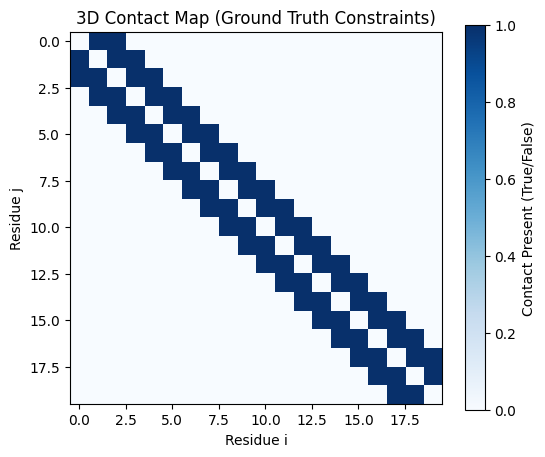

In [6]:
# Generate a 20-residue sequence as a 'beta-hairpin' generic fold
base_sequence_str = "GATAAAAKGATAAAAKGYTG"
pdb_string = generate_pdb_content(sequence_str=base_sequence_str, conformation="beta")

import io

import biotite.structure.io.pdb as pdb_io

pdb_file = pdb_io.PDBFile.read(io.StringIO(pdb_string))
structure = pdb_file.get_structure(model=1)

# Compute distance map and convert to boolean true/false contacts (8 Angstrom threshold)
distogram = compute_contact_map(structure, method="ca", threshold=8.0)
contact_map = (distogram > 0) & (distogram <= 8.0)

# Vizualize Ground Truth Fold
plt.figure(figsize=(6, 5))
plt.imshow(contact_map, cmap='Blues')
plt.title("3D Contact Map (Ground Truth Constraints)")
plt.colorbar(label="Contact Present (True/False)")
plt.xlabel("Residue i")
plt.ylabel("Residue j")
plt.show()

## 2. Markov Chain Monte Carlo Sequence Evolution

A **Potts Model** is a physics framework that scores sequence 'Energy'. A sequence has lower energy (is more stable) if contacting residues pack perfectly together in volume.

We launch a **Metropolis-Hastings MCMC Sampler**. This algorithm proposes random point mutations:
- If standard Steric packing is preserved (Energy stays low) -> the mutation is Accepted.
- If a severe clash occurs (Energy spikes up) -> the mutation is Rejected (with high probability based on `evolution_temperature`).

This creates an MSA of homologous sequences that have drifted far from the ancestor, but *still respect the contact map*.

In [7]:
n_sequences = 1000
evolution_temp = 1.5

print(f"Generating MSA with {n_sequences} homologous sequences...")
msa_list = generate_msa(
    base_sequence=base_sequence_str,
    contact_map=contact_map,
    num_sequences=n_sequences,
    temperature=evolution_temp,
    steps_between_samples=100
)

print("Sample of evolved sequences:")
for seq in msa_list[:5]:
    print("   " + seq)

Generating MSA with 1000 homologous sequences...
Sample of evolved sequences:
   FPNLQLIHSQFPQFLQPDKE
   WPCTPLTNVPNMTEITIQEI
   VNEMELIDVMVINMTQKVSF
   VTQKQNHCIDNKLQGIEALF
   MQECKTVCKQDFEGQVNEVA


## 3. The Evidence: Mutual Information Matrix
If our physical evolutionary simulator worked, residues that touch in the Contact Map must strongly co-vary in the MSA. 
We quantify this using **Shannon Mutual Information (MI)**:

$\text{MI}(i, j) = \sum_{x, y} P_{X,Y}(x, y) \log \frac{P_{X,Y}(x, y)}{P_X(x) P_Y(y)}$

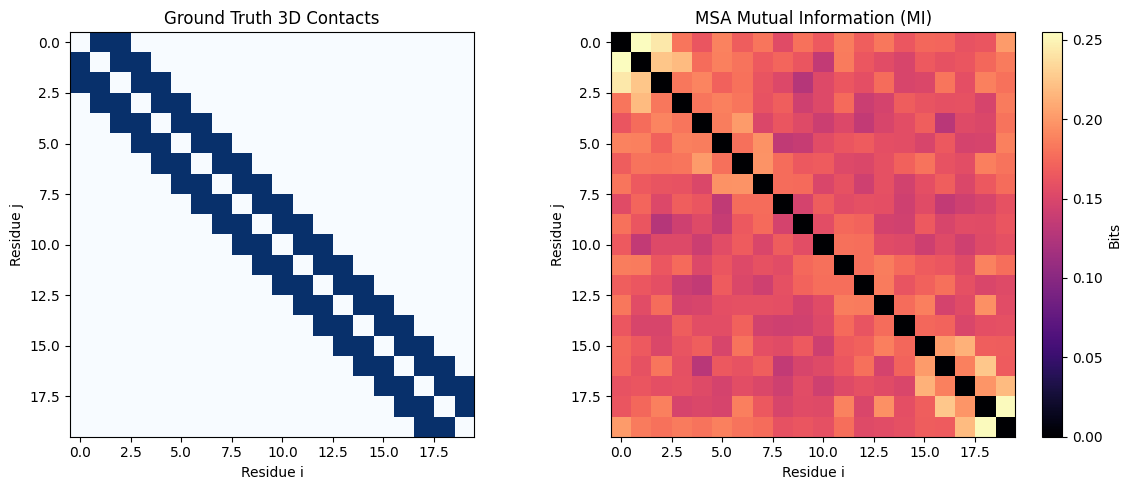

In [8]:
# Convert MSA string list to a numpy char array for column-wise operations
msa_array = np.array([list(seq) for seq in msa_list])
L = msa_array.shape[1]
mi_matrix = np.zeros((L, L))

# Calculate MI for all pairs of columns (i, j)
for i in range(L):
    for j in range(L):
        if i != j:
            # Compute Shannon Mutual Information between column i and column j
            mi_matrix[i, j] = mutual_info_score(msa_array[:, i], msa_array[:, j])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(contact_map, cmap='Blues')
plt.title("Ground Truth 3D Contacts")
plt.xlabel("Residue i")
plt.ylabel("Residue j")

plt.subplot(1, 2, 2)
plt.imshow(mi_matrix, cmap='magma')
plt.title("MSA Mutual Information (MI)")
plt.colorbar(label="Bits")
plt.xlabel("Residue i")
plt.ylabel("Residue j")

plt.tight_layout()
plt.show()

### Conclusion
The Mutual Information matrix (right) perfectly shadows the 3D physical Contact Map (left)! The hot spots of high statistical MI correspond exactly to the structural constraints. 

This is the heart of **Direct Coupling Analysis (DCA)**: by measuring $MI$ from natural sequences in UniProt, structural biologists invert this process to predict the 3D fold. `synth-pdb` gives you the tools to simulate this biophysical phenomenon computationally from scratch.